In [46]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, normal_ad, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

In [8]:
df = pd.read_csv('../Data/ts_demo.csv')
df.head()

,Date,Value
0,1-Jan,16.740344
1,1-Feb,23.871524
2,1-Mar,28.731649
3,1-Apr,33.594409
4,1-May,32.651929


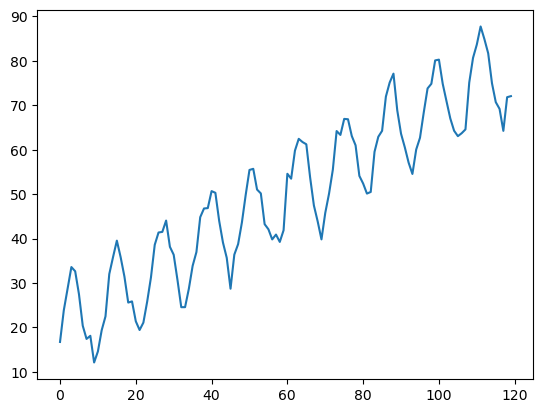

In [11]:
plt.plot(df['Value'])

In [56]:
model = pm.auto_arima(df['Value'], seasonal=True, m=12, trace=True) #AIC used as criterion by default
#model = pm.auto_arima(df['Value'], seasonal=True, m=12, information_criterion='bic', trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=707.977, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=646.265, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=679.122, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=707.156, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=684.128, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=677.120, Time=0.06 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=652.615, Time=0.02 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=645.348, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=684.302, Time=0.02 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=

In [58]:
model = sm.tsa.ARIMA(df['Value'], order=(4, 1, 2))
#model = sm.tsa.ARIMA(df['Value'], order=(4, 1, 2), seasonal_order=(0, 0, 1, 12))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  120
Model:                 ARIMA(4, 1, 2)   Log Likelihood                -280.217
Date:                Fri, 17 Oct 2025   AIC                            574.434
Time:                        09:52:45   BIC                            593.888
Sample:                             0   HQIC                           582.334
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2645      0.102     12.449      0.000       1.065       1.464
ar.L2         -0.4131      0.168     -2.465      0.014      -0.741      -0.085
ar.L3         -0.0838      0.183     -0.457      0.6

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [42]:
#Test for residual autocorrelation (Ljung-Box), p > 0.05 = good
lb_test = acorr_ljungbox(results.resid, lags=[10], return_df=True)
print(lb_test)

#Test for normality (Anderson-Darling), p > 0.05 = good
ad_test = normal_ad(results.resid)
print('AD test statistic:', ad_test[0], 'p-value:', ad_test[1])

#Test for heteroskedasticity (ARCH effects), p > 0.05 = good
arch_test = het_arch(results.resid)
print('ARCH test:', arch_test)

      lb_stat  lb_pvalue
10  13.686777   0.187764
AD test statistic: 0.906063761302704 p-value: 0.02030902785787079
ARCH test: (13.862607596493998, 0.17935125193435464, 1.4275383570761973, 0.17933148309945604)


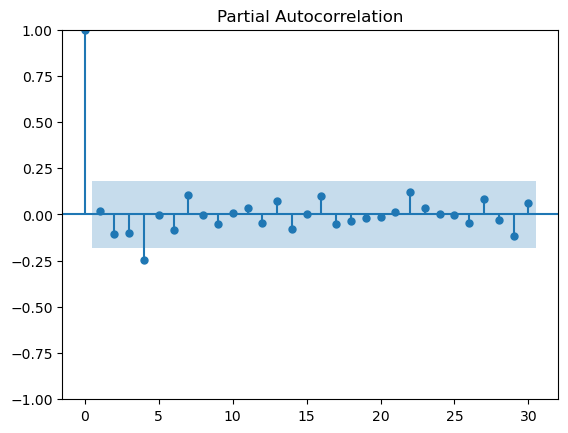

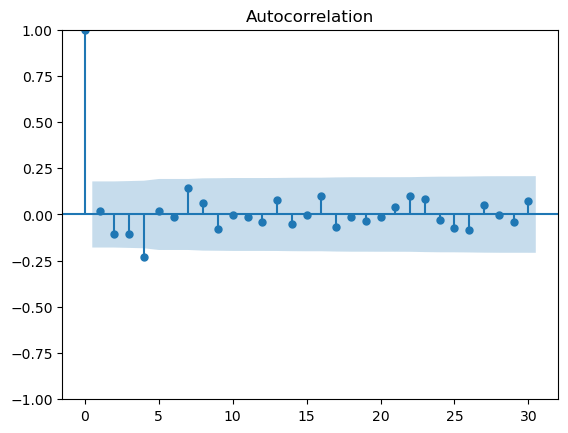

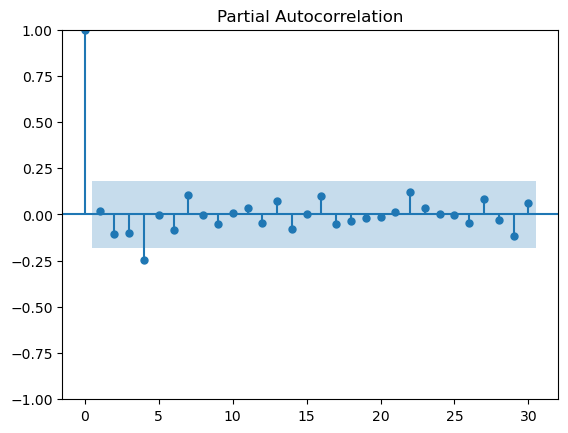

In [50]:
#Residuals need to fall into 95% error bands
plot_acf(results.resid, lags=30)
plot_pacf(results.resid, lags=30)

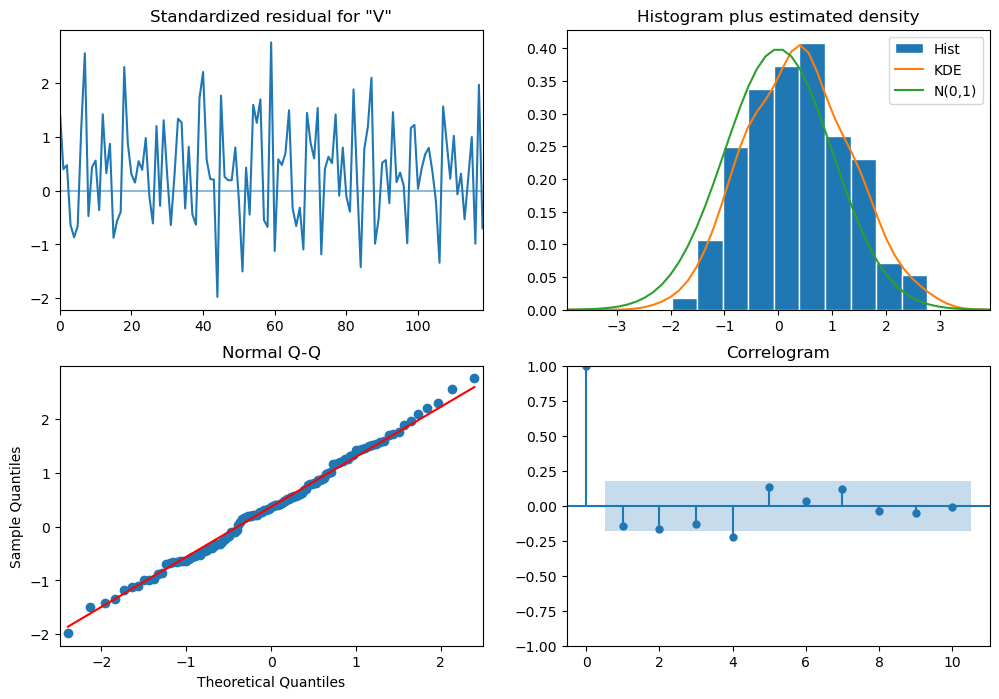

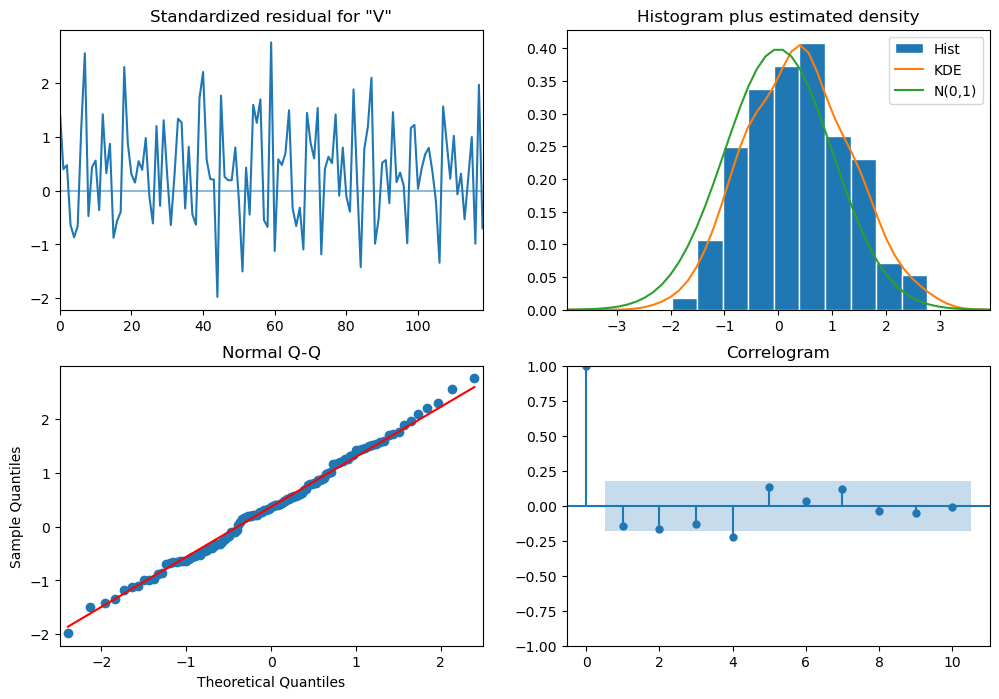

In [52]:
results.plot_diagnostics(figsize=(12, 8))
#Standardized residuals need to be white noise
#Histogram needs to be normal, with a mean of 0
#Q-Q plot needs to be points along the diagonal line
#Correlogram (ACF) autocorrelations within 95% confidence bands

In [28]:
#Forecast 
x = len(df)
forecast = results.predict(start=len(df), end=len(df)+12)

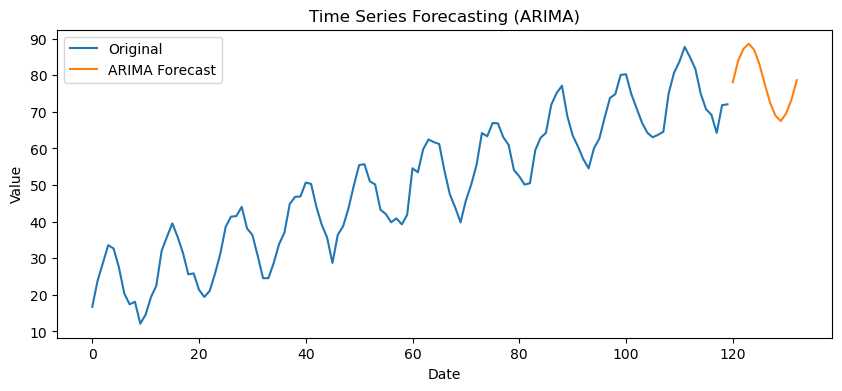

In [30]:
#Plot the original data and the forecasted values
plt.figure(figsize=(10, 4))
plt.plot(df['Value'], label='Original')
plt.plot(forecast, label='ARIMA Forecast')
plt.title('Time Series Forecasting (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='best')
plt.show()